# Análisis descriptivo de variables cuantitativas

Vamos a trabajar con el dataset **adult.data**, cuyo diccionario de datos se puede consultar en la página de [UC Irvine](https://archive.ics.uci.edu/dataset/2/adult).

In [1]:
import pandas as pd

df = pd.read_csv(
    "http://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data",
    header=None,
    names=['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship',
           'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'],
    na_values=[' ?', ' ']
)

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


Evidenciamos que el archivo quedó correctamente cargado, y que los tipos de datos de las variables son correctos.

Ahora procedemos a filtrar las variables cuantitativas.

In [3]:
df = df.select_dtypes(include=['number'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   fnlwgt          32561 non-null  int64
 2   education-num   32561 non-null  int64
 3   capital-gain    32561 non-null  int64
 4   capital-loss    32561 non-null  int64
 5   hours-per-week  32561 non-null  int64
dtypes: int64(6)
memory usage: 1.5 MB



## Creación de tablas de densidades empíricas

Con `value_counts()` se pueden crear estas tablas.

Por ejemplo, para **education-num**, que es una variable discreta, se pueden crear asi:

In [4]:
var = df['education-num']

tabla_discreta = (
    pd.DataFrame(
        {
            "Frec_Absoluta (n_k)": var.value_counts(),
            "Masa_Empirica (p_n)": var.value_counts(normalize=True),
        }
    )
    .sort_index()
    .assign(
        Frec_Acumulada_Abs=lambda df: df["Frec_Absoluta (n_k)"].cumsum(),
        ECDF_Fn=lambda df: df["Masa_Empirica (p_n)"].cumsum(),
    )
)

tabla_discreta

,Frec_Absoluta (n_k),Masa_Empirica (p_n),Frec_Acumulada_Abs,ECDF_Fn
education-num,,,,
1,51,0.001566,51,0.001566
2,168,0.005160,219,0.006726
3,333,0.010227,552,0.016953
4,646,0.019840,1198,0.036792
5,514,0.015786,1712,0.052578
6,933,0.028654,2645,0.081232
7,1175,0.036086,3820,0.117318
8,433,0.013298,4253,0.130616
9,10501,0.322502,14754,0.453119


Para una variable continua, habría que especificar el número de *bins*.

Por ejemplo, vamos a asumir que la variable **fnlwgt** es continua, y vamos a hacer su tabla de distribución empírica:

In [9]:
var = df['fnlwgt']
limites = pd.cut(var, bins=10).cat.categories

tabla_continua = (
    pd.DataFrame(
        {
            "Frec_Absoluta (n_i)": var.value_counts(bins=limites),
            "Densidad_Frecuencia (f_i)": var.value_counts(
                bins=limites, normalize=True
            ),
        }
    )
    .sort_index()
    .assign(
        Distribución_Acumulada=lambda df: df["Densidad_Frecuencia (f_i)"].cumsum(),
        )
)

tabla_continua

,Frec_Absoluta (n_i),Densidad_Frecuencia (f_i),Distribución_Acumulada
"(10812.58, 159527.0]",13117,0.402844,0.402844
"(159527.0, 306769.0]",15327,0.470717,0.873560
"(306769.0, 454011.0]",3498,0.107429,0.980990
"(454011.0, 601253.0]",477,0.014649,0.995639
"(601253.0, 748495.0]",102,0.003133,0.998772
"(748495.0, 895737.0]",20,0.000614,0.999386
"(895737.0, 1042979.0]",10,0.000307,0.999693
"(1042979.0, 1190221.0]",5,0.000154,0.999846
"(1190221.0, 1337463.0]",2,0.000061,0.999908
"(1337463.0, 1484705.0]",3,0.000092,1.000000


## Medidas

Pandas tiene las siguientes funciones para calcular medidas descriptivas:

- Medidas de centralidad: `mean()`, `median()`, `mode()`.
- Medidas de posición: `quantile()`
- Medidas de disperción: `max()`, `min()`, `var()`, `std()`

A partir de estas, es posible calcular otras como **rango muestral**, **rango intercuartílico**, o **coeficiente de variación**.

La función `describe()` genera las estadísticas más importantes.



In [10]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


También es posible usar la función `agg()`para calcular varias medidas al tiempo:

In [13]:
df.agg(['mean', 'median', 'std'])

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
mean,38.581647,189778.366512,10.080679,1077.648844,87.303830,40.437456
median,37.000000,178356.000000,10.000000,0.000000,0.000000,40.000000
std,13.640433,105549.977697,2.572720,7385.292085,402.960219,12.347429


La moda se puede calcular por separado:

In [14]:
df.mode()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
0,36.0,123011,9.0,0.0,0.0,40.0
1,NaN,164190,NaN,NaN,NaN,NaN
2,NaN,203488,NaN,NaN,NaN,NaN


## Gráficos

### Histogramas

En Pandas existe el método `hist()` que permite generar este tipo de gráficos.

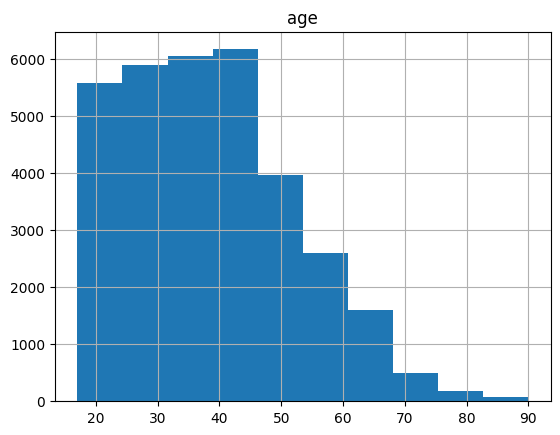

In [17]:
df.hist(column='age');

Es posible configurar el número de bins.

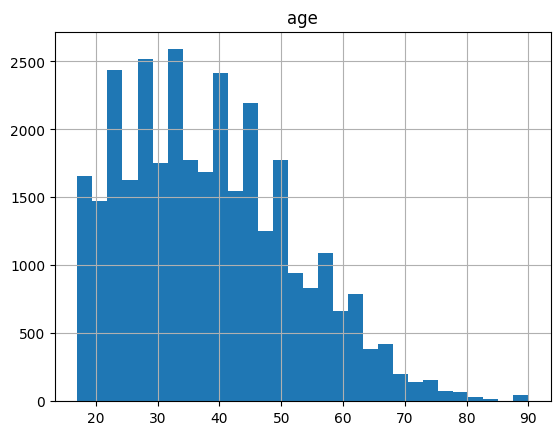

In [18]:
df.hist(column='age', bins=30);

El número óptimo de bins se puede obtener con el parámetro `bins='sturges'`:

array([[<Axes: title={'center': 'age'}>]], dtype=object)

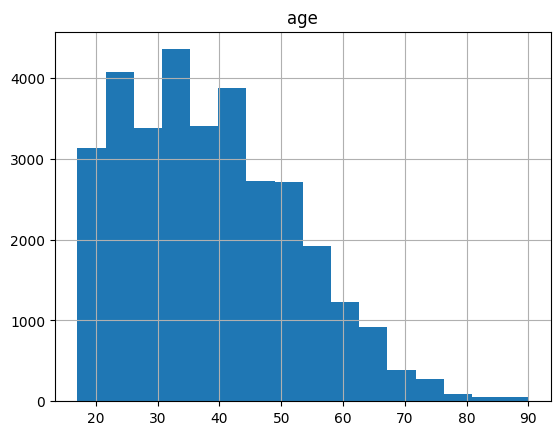

In [19]:
df.hist(column='age', bins='sturges')

### Gráficos de densidad

La función `plot(kind='density'` permite crear gráficos de densidad:

<Axes: ylabel='Density'>

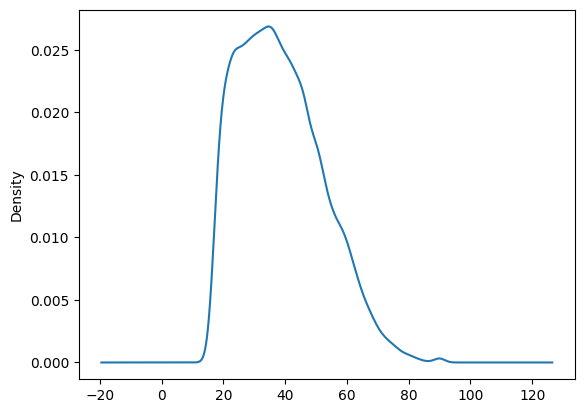

In [20]:
df['age'].plot(kind='density')

También se puede usar la función `plot.kde()`:

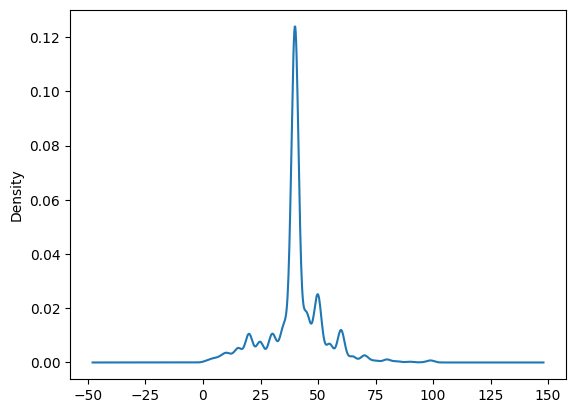

In [23]:
df['hours-per-week'].plot.kde();

También se puede evaluar si las variables cumplen con el supuesto estadístico de normalidad midiendo la [curtosis](https://en.wikipedia.org/wiki/Kurtosis) y la [asimetría](https://en.wikipedia.org/wiki/Skewness) de su distribución. En Pandas es posible hacer esto con las funciones `kurt()`y `skew()`.

La **asimetría** (también conocida como **sesgo**) es una medida estadística que indica el grado de **simetría** de una distribución de datos respecto a su media. En otras palabras, muestra si los datos están más concentrados hacia un lado de la media que hacia el otro. De acuerdo con esto, las variables puden tener:

1. **Asimetría positiva (sesgo a la derecha)**  
   - Valor de asimetría > 0  
   - La cola derecha (valores grandes) es más larga o más pesada.  
   - La mayoría de los datos están concentrados en el lado izquierdo de la media.  
   - Ejemplo: ingresos personales (muchos ganan poco, pocos ganan mucho).

2. **Asimetría negativa (sesgo a la izquierda)**  
   - Valor de asimetría < 0  
   - La cola izquierda (valores pequeños) es más larga o más pesada.  
   - La mayoría de los datos están concentrados en el lado derecho de la media.  
   - Ejemplo: edad de jubilación (la mayoría se jubila a una edad similar, pocos lo hacen muy temprano).

3. **Asimetría nula (simétrica)**  
   - Valor de asimetría ≈ 0  
   - La distribución es simétrica respecto a la media.  
   - Ejemplo: distribución normal.

In [24]:
for num in df.select_dtypes(include=['number']).columns:
    print(f"Asimetría de {num}: {df[num].skew():.3f} \n")

Asimetría de age: 0.559 

Asimetría de fnlwgt: 1.447 

Asimetría de education-num: -0.312 

Asimetría de capital-gain: 11.954 

Asimetría de capital-loss: 4.595 

Asimetría de hours-per-week: 0.228 



¿Qué podemos concluir de estos resultados?

Por otra parte, la **curtosis** es una medida estadística que describe la forma de una distribución, específicamente el grado de concentración de los datos en las colas (extremos) en comparación con una distribución normal. En términos de esta medida podemos hablar de 3 situaciones:

1. **Curtosis normal (mesocúrtica)**
   - Valor de curtosis ≈ 0.
   - La distribución tiene colas similares a las de una distribución normal.
   - Ejemplo: distribución normal estándar.

2. **Curtosis alta (leptocúrtica)**  
   - Valor de curtosis > 0.
   - La distribución tiene colas más pesadas y un pico más alto en el centro.
   - Indica mayor probabilidad de valores extremos (outliers).
   - Ejemplo: distribución t de Student con pocos grados de libertad.

3. **Curtosis baja (platicúrtica)**  
   - Valor de curtosis < 0.
   - La distribución es más plana, con colas más ligeras.
   - Menor probabilidad de valores extremos.
   - Ejemplo: distribución uniforme.

In [25]:
for num in df.select_dtypes(include=['number']).columns:
    print(f"Kurtosis de {num}: {df[num].kurt():.3f} \n")

Kurtosis de age: -0.166 

Kurtosis de fnlwgt: 6.219 

Kurtosis de education-num: 0.623 

Kurtosis de capital-gain: 154.799 

Kurtosis de capital-loss: 20.377 

Kurtosis de hours-per-week: 2.917 



¿Qué podemos concluir de estos resultados?

### Boxplots e identificación de outliers

Los *outliers* son valores atípicos en la muestra. Los *outliers* causan problemas cuando se construyen modelos predictivos, tales como tiempos de entrenamiento más largos, pobre desempeño, e incremento en la varianza del modelo, por lo que es recomendable eliminarlos antes de construir los modelos.

Existen 2 tipos de *outliers*: los univariados que se pueden detectar viendo las distribuciones de los datos mediantes histogramas, o mediante [diagramas de cajas](https://es.wikipedia.org/wiki/Diagrama_de_caja); y los multivariados, que solo se detectan analizando varias variables simultáneamente. Por ahora nos vamos a centrar en los *outliers* univariados.

En un *boxplot*, los puntos por fuera de los bigotes son valores atípicos.

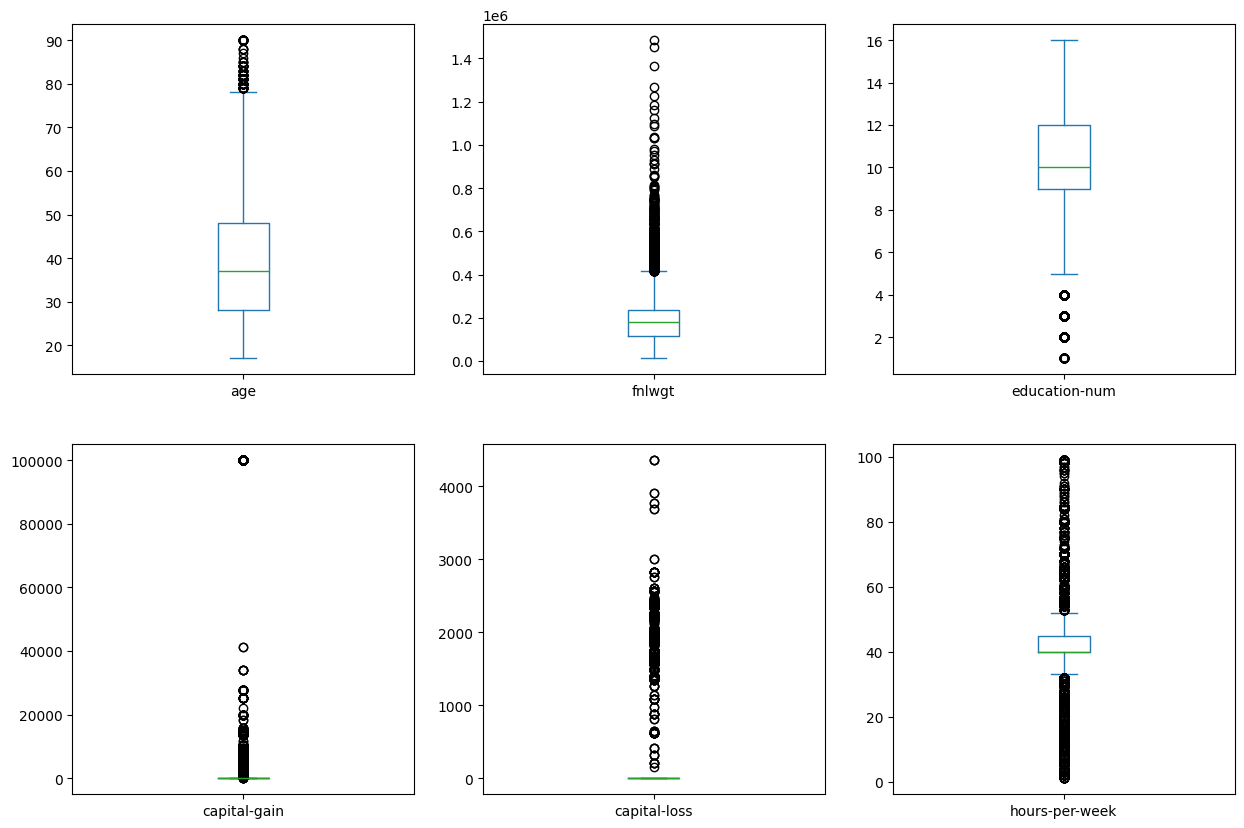

In [26]:
df.plot(kind='box',subplots=True, layout=(2,3), figsize=(15,10), sharey=False, sharex=False);

# Ejercicio

Haga un análisis descriptivo a las variables cuantitativas del archivo de datos "Telco_customer_churn.csv".